# 多层感知机与学习规则

本节从 MNIST 的单层分类器出发，加入隐藏层构成多层感知机（MLP）。随后手工写出一次反向传播（BP）更新，观察分类误差如何从输出层传到隐藏层；最后保持网络结构不变，先比较激活函数，再比较 BP、Oja、GHA 和固定随机特征。

这些实验依次考察三个问题：隐藏层是否改善分类，激活函数如何影响训练，以及不依赖分类误差的局部规则能否学到有用的图像特征。每组对照只改变其中一个因素。

[本课说明与运行步骤](README.md)


In [1]:
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset
from torchvision import datasets, transforms

from biai.paths import DATA_DIR
from biai.reproducibility import seed_everything

SEED = 0
seed_everything(SEED, deterministic=True)
USE_NETWORK_DATA = False
DATASET_DIR = DATA_DIR / "network" if USE_NETWORK_DATA else DATA_DIR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## 准备 MNIST

每张图像是 28 × 28 的灰度图，标签为数字 0–9。`ToTensor()` 将像素缩放到 [0, 1]，模型再把图像展平为 784 维向量。从原训练集固定留出 10% 作为验证集，用于观察每轮学习效果；其余样本按批次打乱训练。测试集只在各模型训练结束后评估一次。课程包已经包含 MNIST；保持 `USE_NETWORK_DATA = False` 会直接读取包内数据，改为 `True` 后则下载到 `data/network/` 并使用该副本。

In [2]:
batch_size = 64
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    root=DATASET_DIR, train=True, download=USE_NETWORK_DATA, transform=transform
)
indices = torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(SEED))
validation_size = len(train_dataset) // 10
validation_indices = indices[:validation_size].tolist()
training_indices = indices[validation_size:].tolist()
val_dataset = Subset(train_dataset, validation_indices)
train_dataset = Subset(train_dataset, training_indices)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = datasets.MNIST(
    root=DATASET_DIR, train=False, download=USE_NETWORK_DATA, transform=transform
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [3]:
print(f"数据集大小: {len(train_dataset)}")
print(f"图像形状: {train_dataset[0][0].shape}")

数据集大小: 54000
图像形状: torch.Size([1, 28, 28])


target: 5


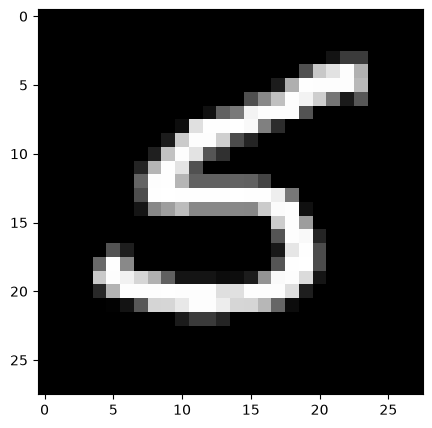

In [4]:
idx = random.sample(range(len(train_dataset)), 1)
image, target = train_dataset[idx[0]]
print(f"target: {target}")

# Convert from CHW to HWC for plotting.
image_np = image.numpy().transpose(1, 2, 0)

fig, ax1 = plt.subplots(1, 1, figsize=(12, 5))
ax1.imshow(image_np.squeeze(), cmap="gray")

## 用反向传播训练

网络为每张图像输出 10 个类别分数（logits），交叉熵损失根据这些分数和真实标签计算误差。一次参数更新依次执行：清空上一批次的梯度、前向计算、反向求导、优化器更新。每轮训练结束后，记录训练集与验证集的交叉熵和准确率。训练指标汇总该轮更新过程中的所有批次，验证指标使用轮末参数。

### 单层线性分类器

输入直接经过一个线性层得到 10 个分数。这个模型没有隐藏层，可作为后续比较的起点。`CrossEntropyLoss` 直接接收分数，从而模型末尾无需添加 softmax。


In [5]:
class MLP_one_linear(nn.Module):
    def __init__(self, input_dim=784, output_dim=10):
        super().__init__()
        # Map 784 pixels to 10 class scores.
        self.fc1 = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        # Flatten each image while keeping the batch dimension.
        x = x.view(x.size(0), -1)
        y = self.fc1(x)
        return y


seed_everything(SEED, deterministic=True)
model = MLP_one_linear(input_dim=784, output_dim=10).to(device)
criterion = nn.CrossEntropyLoss()  # Takes logits, so no separate softmax is needed.
optimizer = optim.SGD(model.parameters(), lr=0.05)

Epoch 1: train loss=0.5937, acc=85.76%; validation loss=0.4187, acc=89.17%
Epoch 2: train loss=0.3806, acc=89.64%; validation loss=0.3700, acc=89.92%
Epoch 3: train loss=0.3471, acc=90.35%; validation loss=0.3482, acc=90.60%
Epoch 4: train loss=0.3296, acc=90.81%; validation loss=0.3366, acc=90.97%
Epoch 5: train loss=0.3182, acc=91.07%; validation loss=0.3281, acc=90.95%
Epoch 6: train loss=0.3101, acc=91.29%; validation loss=0.3227, acc=91.38%
Epoch 7: train loss=0.3041, acc=91.48%; validation loss=0.3174, acc=91.30%
Epoch 8: train loss=0.2990, acc=91.61%; validation loss=0.3162, acc=91.40%
Epoch 9: train loss=0.2949, acc=91.75%; validation loss=0.3120, acc=91.53%
Epoch 10: train loss=0.2914, acc=91.79%; validation loss=0.3112, acc=91.40%
Final test: loss=0.2862, accuracy=91.97%


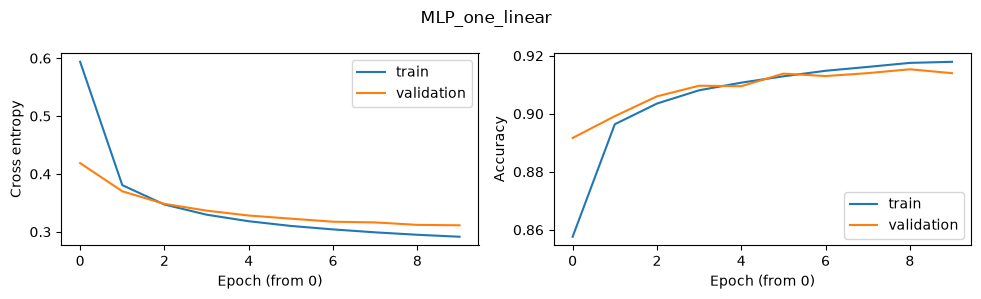

In [6]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    with torch.no_grad():
        for x, target in loader:
            x, target = x.to(device), target.to(device)
            logits = model(x)
            loss_sum += nn.functional.cross_entropy(logits, target, reduction="sum").item()
            correct += (logits.argmax(1) == target).sum().item()
            count += target.numel()
    return loss_sum / count, correct / count


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for split in ("train", "validation"):
        axes[0].plot([row[f"{split}_loss"] for row in history], label=split)
        axes[1].plot([row[f"{split}_accuracy"] for row in history], label=split)
    axes[0].set_ylabel("Cross entropy")
    axes[1].set_ylabel("Accuracy")
    for ax in axes:
        ax.set_xlabel("Epoch (from 0)")
        ax.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def train_classifier(model, optimizer, epochs):
    train_loader.generator.manual_seed(SEED)
    history = []
    for epoch in range(epochs):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for x, target in train_loader:
            x, target = x.to(device), target.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, target)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * target.numel()
            correct += (logits.argmax(1) == target).sum().item()
            count += target.numel()
        val_loss, val_acc = evaluate(model, val_loader)
        history.append(
            dict(
                train_loss=loss_sum / count,
                train_accuracy=correct / count,
                validation_loss=val_loss,
                validation_accuracy=val_acc,
            )
        )
        print(
            f"Epoch {epoch + 1}: train loss={loss_sum / count:.4f}, acc={correct / count:.2%}; "
            f"validation loss={val_loss:.4f}, acc={val_acc:.2%}"
        )
    test_loss, test_acc = evaluate(model, test_loader)
    print(f"Final test: loss={test_loss:.4f}, accuracy={test_acc:.2%}")
    plot_history(history, type(model).__name__)
    return history, test_acc


epochs = 10
linear_history, linear_test_accuracy = train_classifier(model, optimizer, epochs)

### 带一个隐藏层的 MLP

在输入和输出之间加入 128 个隐藏单元，并使用 ReLU 激活。若去掉 ReLU，两个线性层的组合仍然只能表示一个线性变换。此处沿用上一节的学习率、批次大小和训练轮数，比较两种模型的验证曲线及最终测试准确率。

Epoch 1: train loss=0.5940, acc=85.48%; validation loss=0.3445, acc=90.50%
Epoch 2: train loss=0.2999, acc=91.39%; validation loss=0.2823, acc=92.10%
Epoch 3: train loss=0.2495, acc=92.91%; validation loss=0.2457, acc=93.13%
Epoch 4: train loss=0.2146, acc=93.94%; validation loss=0.2155, acc=94.12%
Epoch 5: train loss=0.1874, acc=94.71%; validation loss=0.1965, acc=94.55%
Epoch 6: train loss=0.1664, acc=95.28%; validation loss=0.1810, acc=94.87%
Epoch 7: train loss=0.1496, acc=95.79%; validation loss=0.1679, acc=95.08%
Epoch 8: train loss=0.1350, acc=96.19%; validation loss=0.1619, acc=95.35%
Epoch 9: train loss=0.1228, acc=96.58%; validation loss=0.1466, acc=95.83%
Epoch 10: train loss=0.1125, acc=96.84%; validation loss=0.1426, acc=95.77%
Final test: loss=0.1189, accuracy=96.56%


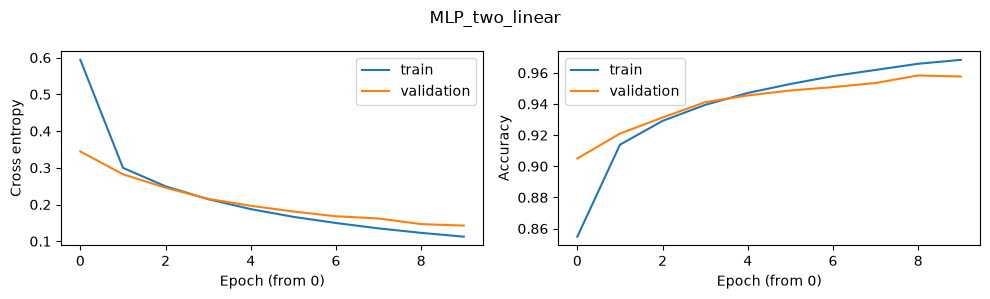

In [7]:
class MLP_two_linear(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, output_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # 784 inputs -> 128 hidden units.
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h = torch.relu(self.fc1(x))  # ReLU makes the two-layer model nonlinear.
        y = self.fc2(h)
        return y


seed_everything(SEED, deterministic=True)
model = MLP_two_linear().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)
epochs = 10
mlp_history, mlp_test_accuracy = train_classifier(model, optimizer, epochs)

## 手工计算反向传播

前面的模型通过 `loss.backward()` 自动求导。下面把两层权重的更新展开：先计算输出误差，再通过输出层权重将误差传回隐藏层。两层梯度都使用更新前的权重，最后一起更新。

权重变化为“误差信号 × 输入活动”的形式，但隐藏层仍需要来自输出层的误差信号，因此属于 BP。后面的 Hebb 示例会展示只依靠输入和隐藏活动的局部更新。

为简化求导，这个手工示例省略了偏置，也采用了不同的初始化方式。它适合用来理解梯度计算；学习规则的效果留到后面的相同初始化对照中比较。


In [8]:
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 64
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1)),  # Flatten each image before batching.
    ]
)

train_dataset = datasets.MNIST(
    root=DATASET_DIR, train=True, download=USE_NETWORK_DATA, transform=transform
)
val_dataset = Subset(train_dataset, validation_indices)
train_dataset = Subset(train_dataset, training_indices)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = datasets.MNIST(
    root=DATASET_DIR, train=False, download=USE_NETWORK_DATA, transform=transform
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_dim = 784  # 28 x 28 pixels.
hidden_dim = 128  # Hidden units.
output_dim = 10  # Digit classes.
eta = 0.05  # Learning rate.

In [9]:
# Scale each layer by its fan-in; this example has no biases.
seed_everything(SEED, deterministic=True)
W1 = torch.randn(hidden_dim, input_dim, device=device) * (2 / input_dim) ** 0.5
W2 = torch.randn(output_dim, hidden_dim, device=device) * (1 / hidden_dim) ** 0.5


def forward(x):
    h = torch.relu(torch.matmul(x, W1.T))
    y = torch.matmul(h, W2.T)
    return h, y


def manual_backprop_update(x, h, y, target):
    global W1, W2
    target_onehot = F.one_hot(target, num_classes=output_dim).float()

    y_pred = torch.softmax(y, dim=1)

    # Average the outer products of output errors and hidden activations.
    error_out = target_onehot - y_pred
    dW2 = eta * torch.matmul(error_out.T, h)
    # Use the same pre-update weights for both layer gradients.
    error_hidden = torch.matmul(error_out, W2) * (h > 0).float()
    dW1 = eta * torch.matmul(error_hidden.T, x)
    W1 += dW1 / x.size(0)
    W2 += dW2 / x.size(0)

Epoch 1: train loss=0.5231, acc=86.42%; validation loss=0.3228, acc=91.27%
Epoch 2: train loss=0.2815, acc=92.02%; validation loss=0.2631, acc=92.62%
Epoch 3: train loss=0.2326, acc=93.38%; validation loss=0.2283, acc=93.60%
Epoch 4: train loss=0.1989, acc=94.33%; validation loss=0.1994, acc=94.48%
Epoch 5: train loss=0.1723, acc=95.11%; validation loss=0.1820, acc=95.08%
Epoch 6: train loss=0.1523, acc=95.69%; validation loss=0.1673, acc=95.20%
Epoch 7: train loss=0.1366, acc=96.13%; validation loss=0.1557, acc=95.75%
Epoch 8: train loss=0.1236, acc=96.55%; validation loss=0.1492, acc=95.70%
Epoch 9: train loss=0.1129, acc=96.87%; validation loss=0.1376, acc=96.05%
Epoch 10: train loss=0.1039, acc=97.14%; validation loss=0.1350, acc=95.90%
Final test: loss=0.1158, accuracy=96.63%


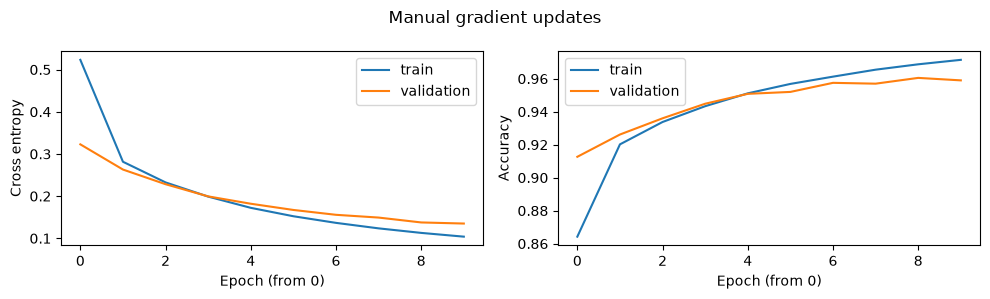

In [10]:
def evaluate_manual(loader):
    loss_sum, correct, count = 0.0, 0, 0
    for x, target in loader:
        x, target = x.to(device), target.to(device)
        _, logits = forward(x)
        loss_sum += F.cross_entropy(logits, target, reduction="sum").item()
        correct += (logits.argmax(1) == target).sum().item()
        count += target.numel()
    return loss_sum / count, correct / count


epochs = 10
manual_history = []
for epoch in range(epochs):
    loss_sum, correct, count = 0.0, 0, 0
    for x, target in train_loader:
        x, target = x.to(device), target.to(device)
        h, y = forward(x)
        loss_sum += F.cross_entropy(y, target, reduction="sum").item()
        correct += (y.argmax(1) == target).sum().item()
        count += target.numel()
        manual_backprop_update(x, h, y, target)
    val_loss, val_acc = evaluate_manual(val_loader)
    manual_history.append(
        dict(
            train_loss=loss_sum / count,
            train_accuracy=correct / count,
            validation_loss=val_loss,
            validation_accuracy=val_acc,
        )
    )
    print(
        f"Epoch {epoch + 1}: train loss={loss_sum / count:.4f}, acc={correct / count:.2%}; "
        f"validation loss={val_loss:.4f}, acc={val_acc:.2%}"
    )
manual_test_loss, manual_test_accuracy = evaluate_manual(test_loader)
print(f"Final test: loss={manual_test_loss:.4f}, accuracy={manual_test_accuracy:.2%}")
plot_history(manual_history, "Manual gradient updates")

## 对照一：激活函数

ReLU 将负值置零，Sigmoid 把输出限制到 $0\sim 1$，Tanh 把输出限制到 $−1\sim 1$。这里保持网络的其余部分不变，观察三种激活函数对学习曲线和分类准确率的影响。

为了把差异限定在激活函数，三个 784→128→10 网络从相同的权重与偏置开始，并使用相同的数据划分、样本顺序和训练轮数。三组都采用学习率为 0.05 的 SGD。


Epoch 1: train loss=0.5940, acc=85.48%; validation loss=0.3445, acc=90.50%
Epoch 2: train loss=0.2999, acc=91.39%; validation loss=0.2823, acc=92.10%
Epoch 3: train loss=0.2495, acc=92.91%; validation loss=0.2457, acc=93.13%
Epoch 4: train loss=0.2146, acc=93.94%; validation loss=0.2155, acc=94.12%
Epoch 5: train loss=0.1874, acc=94.71%; validation loss=0.1965, acc=94.55%
Epoch 6: train loss=0.1664, acc=95.28%; validation loss=0.1810, acc=94.87%
Epoch 7: train loss=0.1496, acc=95.79%; validation loss=0.1679, acc=95.08%
Epoch 8: train loss=0.1350, acc=96.19%; validation loss=0.1619, acc=95.35%
Epoch 9: train loss=0.1228, acc=96.58%; validation loss=0.1466, acc=95.83%
Epoch 10: train loss=0.1125, acc=96.84%; validation loss=0.1426, acc=95.77%
Final test: loss=0.1189, accuracy=96.56%


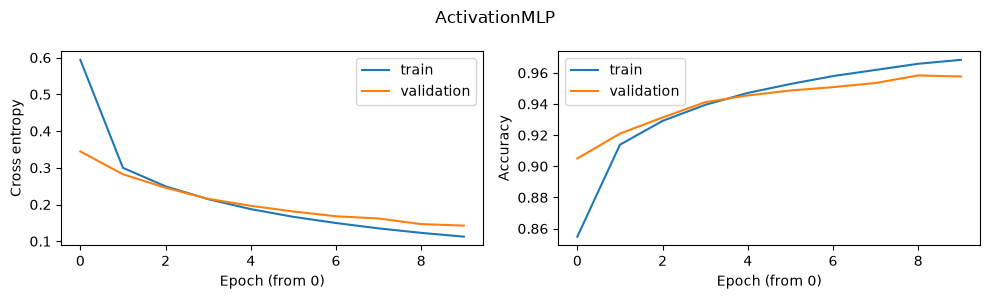

Epoch 1: train loss=1.3482, acc=67.18%; validation loss=0.6843, acc=84.77%
Epoch 2: train loss=0.5336, acc=86.78%; validation loss=0.4535, acc=88.37%
Epoch 3: train loss=0.4064, acc=89.00%; validation loss=0.3858, acc=89.70%
Epoch 4: train loss=0.3582, acc=90.03%; validation loss=0.3529, acc=90.07%
Epoch 5: train loss=0.3313, acc=90.54%; validation loss=0.3314, acc=90.53%
Epoch 6: train loss=0.3131, acc=91.03%; validation loss=0.3181, acc=91.17%
Epoch 7: train loss=0.2995, acc=91.40%; validation loss=0.3058, acc=91.08%
Epoch 8: train loss=0.2882, acc=91.66%; validation loss=0.2992, acc=91.40%
Epoch 9: train loss=0.2782, acc=91.97%; validation loss=0.2888, acc=91.67%
Epoch 10: train loss=0.2695, acc=92.17%; validation loss=0.2823, acc=91.87%
Final test: loss=0.2601, accuracy=92.54%


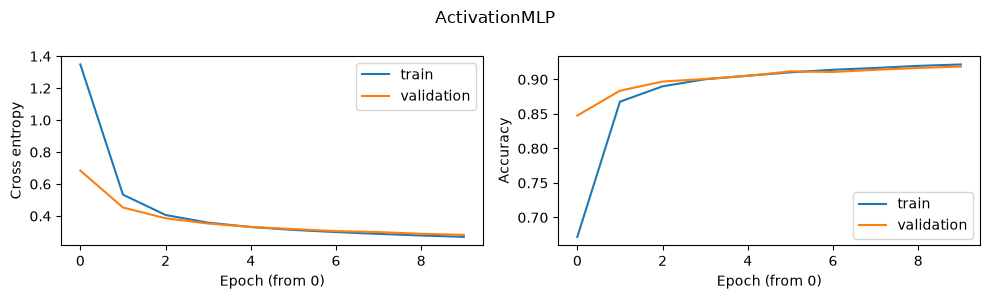

Epoch 1: train loss=0.5810, acc=85.91%; validation loss=0.3540, acc=90.18%
Epoch 2: train loss=0.3119, acc=91.07%; validation loss=0.3026, acc=91.52%
Epoch 3: train loss=0.2717, acc=92.25%; validation loss=0.2727, acc=92.13%
Epoch 4: train loss=0.2429, acc=93.02%; validation loss=0.2468, acc=93.20%
Epoch 5: train loss=0.2182, acc=93.80%; validation loss=0.2267, acc=93.72%
Epoch 6: train loss=0.1971, acc=94.36%; validation loss=0.2101, acc=94.02%
Epoch 7: train loss=0.1795, acc=94.89%; validation loss=0.1953, acc=94.30%
Epoch 8: train loss=0.1642, acc=95.31%; validation loss=0.1868, acc=94.58%
Epoch 9: train loss=0.1513, acc=95.70%; validation loss=0.1728, acc=95.02%
Epoch 10: train loss=0.1400, acc=95.99%; validation loss=0.1666, acc=95.03%
Final test: loss=0.1425, accuracy=95.95%


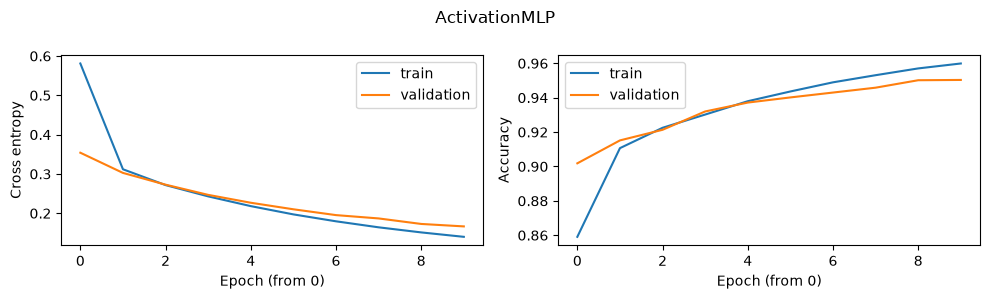

relu     validation=95.77%, test=96.56%
sigmoid  validation=91.87%, test=92.54%
tanh     validation=95.03%, test=95.95%


In [11]:
class ActivationMLP(nn.Module):
    def __init__(self, activation="relu", bias=True):
        super().__init__()
        self.fc1 = nn.Linear(784, 128, bias=bias)
        self.fc2 = nn.Linear(128, 10, bias=bias)
        self.activation = {"relu": nn.ReLU(), "sigmoid": nn.Sigmoid(), "tanh": nn.Tanh()}[
            activation
        ]

    def forward(self, x):
        return self.fc2(self.activation(self.fc1(x.flatten(1))))


seed_everything(SEED, deterministic=True)
activation_initial = ActivationMLP().state_dict()
activation_results = {}
for activation in ("relu", "sigmoid", "tanh"):
    seed_everything(SEED, deterministic=True)
    activation_model = ActivationMLP(activation).to(device)
    activation_model.load_state_dict(activation_initial)
    history, score = train_classifier(
        activation_model, optim.SGD(activation_model.parameters(), lr=0.05), epochs
    )
    activation_results[activation] = dict(history=history, test_accuracy=score)
for name, result in activation_results.items():
    print(
        f"{name:8s} validation={result['history'][-1]['validation_accuracy']:.2%}, "
        f"test={result['test_accuracy']:.2%}"
    )

## 对照二：用局部规则学习隐藏特征

前面的网络都用 BP 训练隐藏层：分类误差从输出层传回特征层，指导每个权重如何变化。接下来换一种思路，隐藏层不再接收分类误差，只根据当前输入 $x$ 和自身响应 $y$ 更新权重；分类层仍然使用标签训练。

最简单的 Hebb 更新会累加 $yx^\top$，使同时活跃的输入和神经元连接得更强，但反复更新也会使权重持续增大。[Oja 规则](https://users.ics.aalto.fi/oja/papers.html) 加入稳定项来限制这种增长。多个单元各自使用 Oja 规则时，仍可能学到相似的方向；[Sanger 的广义 Hebb 规则（GHA）](https://proceedings.neurips.cc/paper_files/paper/1988/file/e00da03b685a0dd18fb6a08af0923de0-Paper.pdf) 会在更新后面的单元时减去前面单元已经表示的成分，以减少特征重复。

实验比较四个结构相同、均不含偏置的网络：

| 方法 | 特征层如何更新 | 分类层如何更新 |
| --- | --- | --- |
| BP | 根据分类误差反向传播 | 根据分类误差更新 |
| Oja | 根据输入和隐藏活动作局部更新 | 根据分类误差更新 |
| GHA | 在局部更新中减少特征重复 | 根据分类误差更新 |
| 固定随机特征 | 保持初始权重 | 根据分类误差更新 |

四个网络从相同参数开始，并按相同顺序读取训练批次。分类层都采用 0.05 的学习率；Oja 与 GHA 的特征层学习率为 0.001。固定随机特征保留初始隐藏层，只训练分类层，作为衡量局部特征学习是否有效的基线。

读结果时可先观察分类准确率，它反映隐藏特征是否适合数字识别；再观察隐藏权重的平均绝对余弦，它反映不同单元学到的方向是否重复。其接近 1，则说明许多权重方向相似；接近 0，则说明这些方向更分散。更新公式和数据中心化的影响详见附录。


BP epoch 1: validation=90.43%
BP epoch 2: validation=92.15%
BP epoch 3: validation=93.22%
BP epoch 4: validation=94.08%
BP epoch 5: validation=94.50%
BP epoch 6: validation=94.92%
BP epoch 7: validation=95.43%
BP epoch 8: validation=95.45%
BP epoch 9: validation=95.85%
BP epoch 10: validation=95.90%


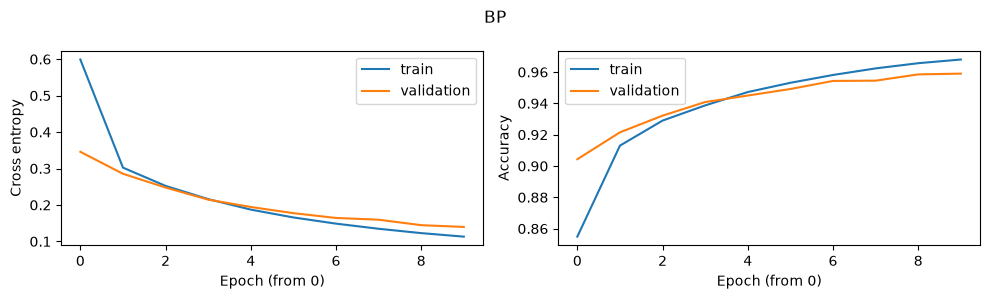

Oja epoch 1: validation=9.30%
Oja epoch 2: validation=10.65%
Oja epoch 3: validation=9.23%
Oja epoch 4: validation=9.90%
Oja epoch 5: validation=9.23%
Oja epoch 6: validation=9.23%
Oja epoch 7: validation=10.18%
Oja epoch 8: validation=9.30%
Oja epoch 9: validation=9.23%
Oja epoch 10: validation=9.90%


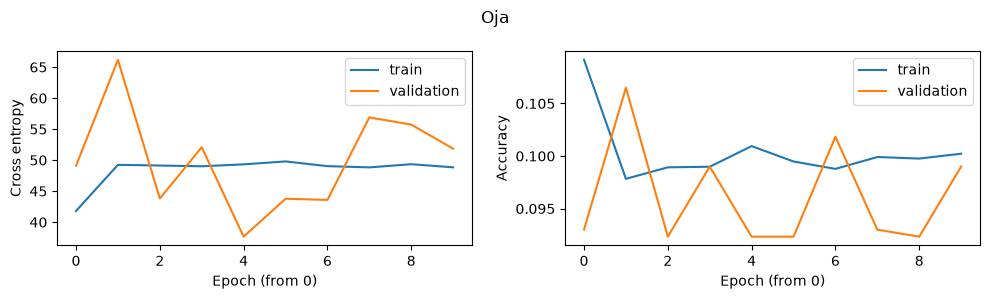

GHA epoch 1: validation=77.58%
GHA epoch 2: validation=81.50%
GHA epoch 3: validation=83.02%
GHA epoch 4: validation=81.87%
GHA epoch 5: validation=82.55%
GHA epoch 6: validation=82.72%
GHA epoch 7: validation=82.22%
GHA epoch 8: validation=81.97%
GHA epoch 9: validation=82.87%
GHA epoch 10: validation=82.60%


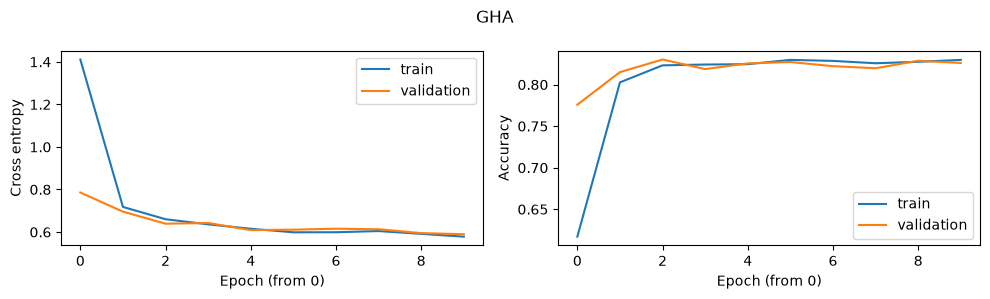

Frozen epoch 1: validation=70.25%
Frozen epoch 2: validation=74.40%
Frozen epoch 3: validation=75.87%
Frozen epoch 4: validation=76.97%
Frozen epoch 5: validation=77.95%
Frozen epoch 6: validation=78.65%
Frozen epoch 7: validation=79.18%
Frozen epoch 8: validation=79.58%
Frozen epoch 9: validation=79.87%
Frozen epoch 10: validation=80.38%


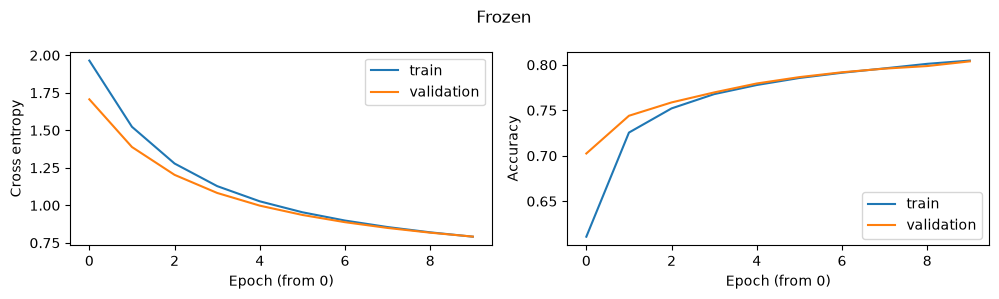

BP       validation=95.90%, test=96.47%, feature |cos|=0.1083
Oja      validation=9.90%, test=10.09%, feature |cos|=1.0000
GHA      validation=82.60%, test=83.93%, feature |cos|=0.0628
Frozen   validation=80.38%, test=81.57%, feature |cos|=0.0286


In [12]:
@torch.no_grad()
def oja_update(layer, x, learning_rate):
    """Update a bias-free feature layer using activities, without labels or feedback."""
    x = x.flatten(1)
    y = x @ layer.weight.T
    correlation = y.T @ x / x.shape[0]
    stabilization = y.square().mean(0)[:, None] * layer.weight
    layer.weight.add_(learning_rate * (correlation - stabilization))


@torch.no_grad()
def generalized_hebbian_update(layer, x, learning_rate):
    """Use Sanger's lower-triangular activity term to learn distinct directions."""
    x = x.flatten(1)
    y = x @ layer.weight.T
    correlation = y.T @ x
    decorrelation = torch.tril(y.T @ y) @ layer.weight
    layer.weight.add_(learning_rate * (correlation - decorrelation) / x.shape[0])


def train_learning_rule(model, rule, epochs):
    feature_learning = rule == "BP"
    model.fc1.weight.requires_grad_(feature_learning)
    parameters = model.parameters() if feature_learning else model.fc2.parameters()
    optimizer = optim.SGD(parameters, lr=0.05)
    train_loader.generator.manual_seed(SEED)
    history = []
    for epoch in range(epochs):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for x, target in train_loader:
            x, target = x.to(device), target.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, target)
            loss.backward()
            optimizer.step()
            if rule == "Oja":
                oja_update(model.fc1, x, learning_rate=0.001)
            elif rule == "GHA":
                generalized_hebbian_update(model.fc1, x, learning_rate=0.001)
            loss_sum += loss.item() * target.numel()
            correct += (logits.argmax(1) == target).sum().item()
            count += target.numel()
        val_loss, val_acc = evaluate(model, val_loader)
        history.append(
            dict(
                train_loss=loss_sum / count,
                train_accuracy=correct / count,
                validation_loss=val_loss,
                validation_accuracy=val_acc,
            )
        )
        print(f"{rule} epoch {epoch + 1}: validation={val_acc:.2%}")
    _, score = evaluate(model, test_loader)
    plot_history(history, rule)
    directions = F.normalize(model.fc1.weight.detach(), dim=1)
    similarity = (directions @ directions.T).abs()
    off_diagonal = ~torch.eye(len(directions), dtype=torch.bool, device=device)
    return dict(
        history=history,
        test_accuracy=score,
        mean_abs_feature_cosine=similarity[off_diagonal].mean().item(),
    )


seed_everything(SEED, deterministic=True)
rule_initial = ActivationMLP(bias=False).state_dict()
rule_results = {}
for rule in ("BP", "Oja", "GHA", "Frozen"):
    seed_everything(SEED, deterministic=True)
    rule_model = ActivationMLP(bias=False).to(device)
    rule_model.load_state_dict(rule_initial)
    rule_results[rule] = train_learning_rule(rule_model, rule, epochs)
for name, result in rule_results.items():
    print(
        f"{name:8s} validation={result['history'][-1]['validation_accuracy']:.2%}, "
        f"test={result['test_accuracy']:.2%}, feature |cos|={result['mean_abs_feature_cosine']:.4f}"
    )

## 问题

如何设计效果更好的学习算法？

“效果更好”可以有不同含义，例如更高的分类准确率、更快或更稳定的学习、更少的特征重复、更低的计算成本，或者更符合局部学习的要求。可以改进本节介绍的学习规则，也可以提出其他方法。

下面列出几个可供参考的方向。注意，**这些方向不是必须完成的任务，也不限定问题的范围。**

1. **输入的统计性质**

   学习规则接收到什么样的输入，会影响它最终学到的特征。例如，对输入减去训练集的平均图像后，Oja 和 GHA 处理的将不再是原始二阶矩，而是与协方差有关的方向。可以进一步思考：学习算法是否应当显式利用输入的均值、方差或其他统计量？

   进一步阅读：Erkki Oja, [*A Simplified Neuron Model as a Principal Component Analyzer*](https://doi.org/10.1007/BF00275687)；Terence Sanger, [*Optimal Unsupervised Learning in a Single-Layer Linear Feedforward Neural Network*](https://www.sciencedirect.com/science/article/abs/pii/0893608089900440)。

2. **学习过程随时间变化**

   当前 Oja 和 GHA 在整个训练过程中使用固定的特征学习率。学习算法也可以在训练早期进行较大的更新，在后期逐渐减小更新幅度；更新强度还可以依赖神经元活动、权重状态或近期的学习效果。可以思考：学习速度和最终稳定性之间应当如何取舍？

   进一步阅读：Erkki Oja 与 Juha Karhunen, [*On Stochastic Approximation of the Eigenvectors and Eigenvalues of the Expectation of a Random Matrix*](https://users.ics.aalto.fi/oja/OjaKarhunen1985.pdf)。

3. **隐藏单元之间的相互作用**

   当前 Oja 单元基本独立地学习，GHA 则按固定顺序减少特征重复。另一种思路是让隐藏单元相互竞争，例如让响应较强的单元获得更多更新，或使用稀疏活动、侧向抑制等机制促进单元分工。竞争能够增加特征多样性，但也可能使部分单元很少得到更新。

   进一步阅读：Dmitry Krotov 与 John Hopfield, [*Unsupervised Learning by Competing Hidden Units*](https://pmc.ncbi.nlm.nih.gov/articles/PMC6475390/)。

## 附录：Oja 与 GHA 的更新量

对于一个样本，Oja 规则写作 $\Delta w_j=\eta(y_jx-y_j^2w_j)$，其中 $y_j=w_j^\top x$。第一项是 Hebb 更新，第二项限制权重增长；代码对一个批次中的更新取平均。计算只需要输入 $x$ 和当前单元的响应 $y_j$，而 BP 还需要标签产生的分类误差。

GHA 将减去的部分扩展为 $\sum_{k\leq j}y_jy_kw_k$，因此 $\Delta w_j=\eta[y_jx-\sum_{k\leq j}y_jy_kw_k]$。代码中的 `tril()` 保留下三角，使第 $j$ 个单元扣除自身以及此前单元已经表示的方向。Oja 和 GHA 都使用 ReLU 之前的线性响应更新特征层，分类层读取的则是经过 ReLU 的隐藏活动。

这里沿用前面模型的数据处理方式，只把像素缩放到 $[0,1]$，没有减去训练集的平均图像。因此，GHA 朝 $E[xx^\top]$ 的主要方向更新；如果先减去平均图像，它追踪的才是协方差矩阵的主成分。本实验采用前一种处理，使四组模型接收完全相同的输入。